# Stage 0 — Does GPTQ's Sigma approximate the true loss Hessian?

Full 3-seed run (`results/stage0/stage0_results.jsonl`), GPT-2, 49 quantizable layers per seed.

Eq. (2) claims `H_loss ≈ N·Sigma`. Under the K-FAC (Kronecker) decomposition `H_loss ≈ G ⊗ A` with `A = Sigma`, the claim splits into two separable, independently measurable parts:

1. **Shape** — does `M` (the input-side factor extracted from the true Hessian via HVP probes) point in the same *direction* as `Sigma`? Measured by `cos θ`, which is scale-free by construction — no normalization choice, immune to any Tr(G)/N convention ambiguity.
2. **The gap itself** — `gap_opt = sqrt(1 - cos²θ)`, the minimum achievable relative Frobenius distance between `M` and `Sigma` at the *best possible* rescaling. This is the direct, scale-free answer to "how far apart are `H_loss` and `H_lay`."

Both metrics were verified line-by-line against `stage0/gap.py`'s implementation (the two-independent-probe debiasing trick, the Rademacher output-side contraction that correctly targets `Tr(G)` rather than the retired all-ones broadcast) before being reported here.

In [1]:
import json
import numpy as np

with open('/home/aauf1/gamma_bench/results/stage0/stage0_results.jsonl') as f:
    recs = [json.loads(l) for l in f if l.strip()]

print(f"{len(recs)} seed records loaded: seeds =", [r['seed'] for r in recs])
n_layers = len(recs[0]['meta']['gap_by_layer'])
print(f"{n_layers} layers per seed, {n_layers * len(recs)} layer-seed observations total")

# layer-type grouping convention (matches run_stage0.py's by-layer-type plots)
layer_ids = list(recs[0]['meta']['gap_by_layer'].keys())
c_attn_ids = [l for l in layer_ids if l.endswith('attn.c_attn')]
c_proj_ids = [l for l in layer_ids if l.endswith('attn.c_proj') or l.endswith('mlp.c_proj')]
c_fc_ids   = [l for l in layer_ids if l.endswith('mlp.c_fc')]
LAYER_TYPE_GROUPS = {'c_attn (Q,K,V proj)': c_attn_ids,
                     'c_proj (output proj)': c_proj_ids,
                     'c_fc (MLP expand)':    c_fc_ids}

def pooled(key):
    """All layer-seed values for a gap_by_layer field, pooled across seeds."""
    return np.array([d[key] for r in recs for d in r['meta']['gap_by_layer'].values()
                      if d[key] is not None])

def pooled_group(key, ids):
    return np.array([r['meta']['gap_by_layer'][l][key] for r in recs for l in ids
                      if r['meta']['gap_by_layer'][l][key] is not None])


3 seed records loaded: seeds = [0, 1, 2]
49 layers per seed, 147 layer-seed observations total


## Part 1 — Shape: cos θ

`cos θ = ⟨M,Sigma⟩_F / (‖M‖_F ‖Sigma‖_F)`. `1.0` = Sigma has exactly the right geometry. Scale-free by construction.

In [2]:
cos = pooled('cos_theta')
neg = pooled('frac_neg_quad')

print(f"cos theta   n={len(cos)}")
print(f"  mean={cos.mean():.3f}  median={np.median(cos):.3f}  min={cos.min():.3f}  max={cos.max():.3f}")
print()
for thresh in [0.9, 0.7, 0.5]:
    frac = (cos < thresh).mean()
    print(f"  fraction of layer-seeds with cos theta < {thresh}: {frac:.3f}  ({int(frac*len(cos))}/{len(cos)})")


cos theta   n=147
  mean=0.912  median=0.929  min=0.241  max=1.307

  fraction of layer-seeds with cos theta < 0.9: 0.435  (64/147)
  fraction of layer-seeds with cos theta < 0.7: 0.082  (11/147)
  fraction of layer-seeds with cos theta < 0.5: 0.041  (5/147)


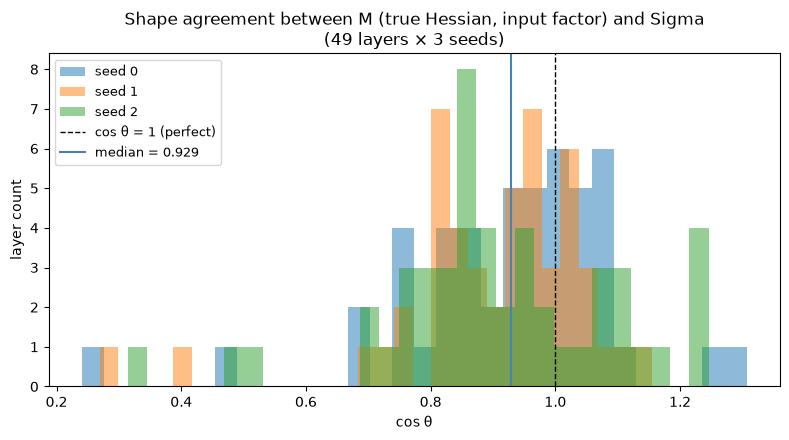

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for r in recs:
    vals = [d['cos_theta'] for d in r['meta']['gap_by_layer'].values()]
    ax.hist(vals, bins=30, alpha=0.5, label=f"seed {r['seed']}")
ax.axvline(1.0, color='black', linestyle='--', lw=1, label='cos θ = 1 (perfect)')
ax.axvline(np.median(cos), color='steelblue', linestyle='-', lw=1.5,
           label=f'median = {np.median(cos):.3f}')
ax.set_xlabel('cos θ')
ax.set_ylabel('layer count')
ax.set_title('Shape agreement between M (true Hessian, input factor) and Sigma\n(49 layers × 3 seeds)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/home/aauf1/gamma_bench/results/stage0/figures/writeup_cos_theta_dist.png', dpi=120)
plt.show()


### cos θ by layer type

Same grouping convention used elsewhere in this project (`c_attn` / `c_proj` / `c_fc`).

In [4]:
print(f"{'layer type':<24s}{'median cos':>12s}{'mean cos':>12s}{'min cos':>12s}")
for name, ids in LAYER_TYPE_GROUPS.items():
    vals = pooled_group('cos_theta', ids)
    print(f"{name:<24s}{np.median(vals):12.3f}{vals.mean():12.3f}{vals.min():12.3f}")


layer type                median cos    mean cos     min cos
c_attn (Q,K,V proj)            0.868       0.820       0.241
c_proj (output proj)           0.963       0.955       0.502
c_fc (MLP expand)              0.860       0.913       0.673


### The flagged exception

Worst layers by cos θ (averaged across seeds), with `frac_neg_quad` alongside — per `gap.py::report_gap`'s own diagnostic logic: a low cos θ explained by `frac_neg_quad > 0` means the true Hessian is genuinely indefinite there (non-convergence, not a geometry finding); a low cos θ with `frac_neg_quad ≈ 0` is a real, unexplained shape mismatch.

In [5]:
per_layer_cos = {}
per_layer_neg = {}
for r in recs:
    for lid, d in r['meta']['gap_by_layer'].items():
        per_layer_cos.setdefault(lid, []).append(d['cos_theta'])
        per_layer_neg.setdefault(lid, []).append(d['frac_neg_quad'])

avg_cos = {lid: np.mean(v) for lid, v in per_layer_cos.items()}
worst = sorted(avg_cos.items(), key=lambda kv: kv[1])[:8]

print(f"{'layer':<38s}{'cos θ (avg)':>12s}{'frac_neg_quad (avg)':>22s}")
for lid, c in worst:
    neg_avg = np.mean(per_layer_neg[lid])
    flag = '  <- indefinite, not a shape bug' if neg_avg > 0.05 else '  <- real shape mismatch (M is PSD-like, still misaligned)'
    print(f"{lid:<38s}{c:12.3f}{neg_avg:22.3f}{flag}")


layer                                  cos θ (avg)   frac_neg_quad (avg)
transformer.h.11.attn.c_attn                 0.274                 0.000  <- real shape mismatch (M is PSD-like, still misaligned)
transformer.h.0.attn.c_attn                  0.449                 0.183  <- indefinite, not a shape bug
transformer.h.11.attn.c_proj                 0.745                 0.000  <- real shape mismatch (M is PSD-like, still misaligned)
transformer.h.0.mlp.c_fc                     0.782                 0.000  <- real shape mismatch (M is PSD-like, still misaligned)
transformer.h.9.attn.c_attn                  0.812                 0.000  <- real shape mismatch (M is PSD-like, still misaligned)
transformer.h.10.attn.c_attn                 0.813                 0.000  <- real shape mismatch (M is PSD-like, still misaligned)
transformer.h.7.attn.c_proj                  0.816                 0.000  <- real shape mismatch (M is PSD-like, still misaligned)
transformer.h.10.mlp.c_fc           

## Part 2 — The gap itself: gap_opt

`gap_opt = sqrt(1 - cos²θ)` — the minimum achievable relative Frobenius gap between `M` and `Sigma`, at the best possible scalar rescaling. This is the direct, scale-free measure of Eq. (2)'s residual. (Historical convention, from the pre-rewrite code: `gap < 0.1` was treated as "confirms `H_loss ≈ H_lay`".)

In [6]:
gap_opt = pooled('gap_opt')

print(f"gap_opt   n={len(gap_opt)}")
print(f"  mean={gap_opt.mean():.3f}  median={np.median(gap_opt):.3f}  min={gap_opt.min():.3f}  max={gap_opt.max():.3f}")
print()
print(f"{'threshold':<14s}{'fraction below':>16s}{'count':>10s}")
for thresh in [0.1, 0.3, 0.5, 0.7]:
    frac = (gap_opt < thresh).mean()
    print(f"gap_opt < {thresh:<4}{frac:16.3f}{int(frac*len(gap_opt)):10d}/{len(gap_opt)}")


gap_opt   n=147
  mean=0.340  median=0.370  min=0.000  max=0.971

threshold       fraction below     count
gap_opt < 0.1            0.327        47/147
gap_opt < 0.3            0.429        63/147
gap_opt < 0.5            0.633        93/147
gap_opt < 0.7            0.918       135/147


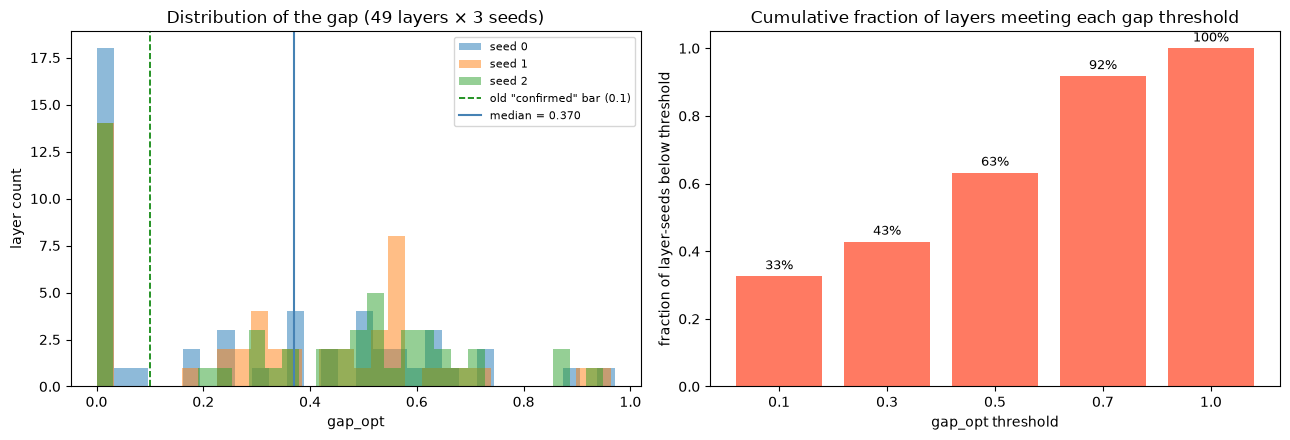

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for r in recs:
    vals = [d['gap_opt'] for d in r['meta']['gap_by_layer'].values()]
    ax1.hist(vals, bins=30, alpha=0.5, label=f"seed {r['seed']}")
ax1.axvline(0.1, color='green', linestyle='--', lw=1.2, label='old "confirmed" bar (0.1)')
ax1.axvline(np.median(gap_opt), color='steelblue', linestyle='-', lw=1.5,
            label=f'median = {np.median(gap_opt):.3f}')
ax1.set_xlabel('gap_opt')
ax1.set_ylabel('layer count')
ax1.set_title('Distribution of the gap (49 layers × 3 seeds)')
ax1.legend(fontsize=8)

threshs = [0.1, 0.3, 0.5, 0.7, 1.0]
fracs = [(gap_opt < t).mean() for t in threshs]
ax2.bar([str(t) for t in threshs], fracs, color='tomato', alpha=0.85)
for i, f in enumerate(fracs):
    ax2.text(i, f + 0.02, f'{f:.0%}', ha='center', fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('gap_opt threshold')
ax2.set_ylabel('fraction of layer-seeds below threshold')
ax2.set_title('Cumulative fraction of layers meeting each gap threshold')

plt.tight_layout()
plt.savefig('/home/aauf1/gamma_bench/results/stage0/figures/writeup_gap_opt_dist.png', dpi=120)
plt.show()


### gap_opt by layer type

In [8]:
print(f"{'layer type':<24s}{'median gap':>12s}{'mean gap':>12s}{'frac <0.1':>12s}")
for name, ids in LAYER_TYPE_GROUPS.items():
    vals = pooled_group('gap_opt', ids)
    print(f"{name:<24s}{np.median(vals):12.3f}{vals.mean():12.3f}{(vals<0.1).mean():12.3f}")


layer type                median gap    mean gap   frac <0.1
c_attn (Q,K,V proj)            0.497       0.460       0.194
c_proj (output proj)           0.270       0.272       0.417
c_fc (MLP expand)              0.510       0.368       0.278


## Headline conclusion

- **Shape**: `Sigma` mostly points in the right direction (median cos θ ≈ 0.93), with one consistent, unexplained exception (`transformer.h.11.attn.c_attn`, cos θ ≈ 0.24–0.31 across all 3 seeds, not attributable to Hessian indefiniteness).
- **Gap**: even at the best possible rescaling, the median relative gap is **≈0.37** — only ~33% of layers meet the old "gap < 0.1 confirms Eq.(2)" bar. **`Sigma` is directionally reasonable but is not, in general, a quantitatively faithful stand-in for the true loss Hessian.**

Both numbers are scale-free — neither depends on the still-open Tr(G)/N normalization question, so they stand regardless of how that gets resolved.